In [1]:
# =========================================================
# SOIL CLASSIFICATION CNN PROJECT
# JUPYTER NOTEBOOK COMPLETE CODE
# Dataset downloaded in same working folder
# =========================================================

# =========================================================
# CELL 1 — INSTALL LIBRARIES
# =========================================================

!pip install kaggle kagglehub tensorflow matplotlib -q


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# =========================================================
# CELL 2 — IMPORT LIBRARIES
# =========================================================

import os
import shutil
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import kagglehub

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
destination_folder = r"C:\Users\prince raj\CNN MODEL FOR SOIL QUALITY ANALYSIS"

print(destination_folder)

C:\Users\prince raj\CNN MODEL FOR SOIL QUALITY ANALYSIS


In [4]:
dataset_download_path = kagglehub.dataset_download(
    "ai4a-lab/comprehensive-soil-classification-datasets"
)

print(dataset_download_path)

C:\Users\prince raj\.cache\kagglehub\datasets\ai4a-lab\comprehensive-soil-classification-datasets\versions\1


In [5]:
final_dataset_path = os.path.join(
    destination_folder,
    "soil_dataset"
)

shutil.copytree(
    dataset_download_path,
    final_dataset_path,
    dirs_exist_ok=True
)

print("Dataset Copied Successfully!")
print(final_dataset_path)

Dataset Copied Successfully!
C:\Users\prince raj\CNN MODEL FOR SOIL QUALITY ANALYSIS\soil_dataset


In [6]:
os.listdir(final_dataset_path)

['.ipynb_checkpoints',
 'CyAUG-Dataset',
 'Orignal-Dataset',
 'SOILANALYSIS CNN.ipynb']

In [7]:
dataset_path = os.path.join(
    final_dataset_path,
    "CyAUG-Dataset"
)

print(dataset_path)

C:\Users\prince raj\CNN MODEL FOR SOIL QUALITY ANALYSIS\soil_dataset\CyAUG-Dataset


In [8]:
print(os.listdir(dataset_path))

['Alluvial_Soil', 'Arid_Soil', 'Black_Soil', 'Laterite_Soil', 'Mountain_Soil', 'Red_Soil', 'Yellow_Soil']


In [9]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 4080 images belonging to 7 classes.
Found 1016 images belonging to 7 classes.


In [11]:
print(train_data.class_indices)

{'Alluvial_Soil': 0, 'Arid_Soil': 1, 'Black_Soil': 2, 'Laterite_Soil': 3, 'Mountain_Soil': 4, 'Red_Soil': 5, 'Yellow_Soil': 6}


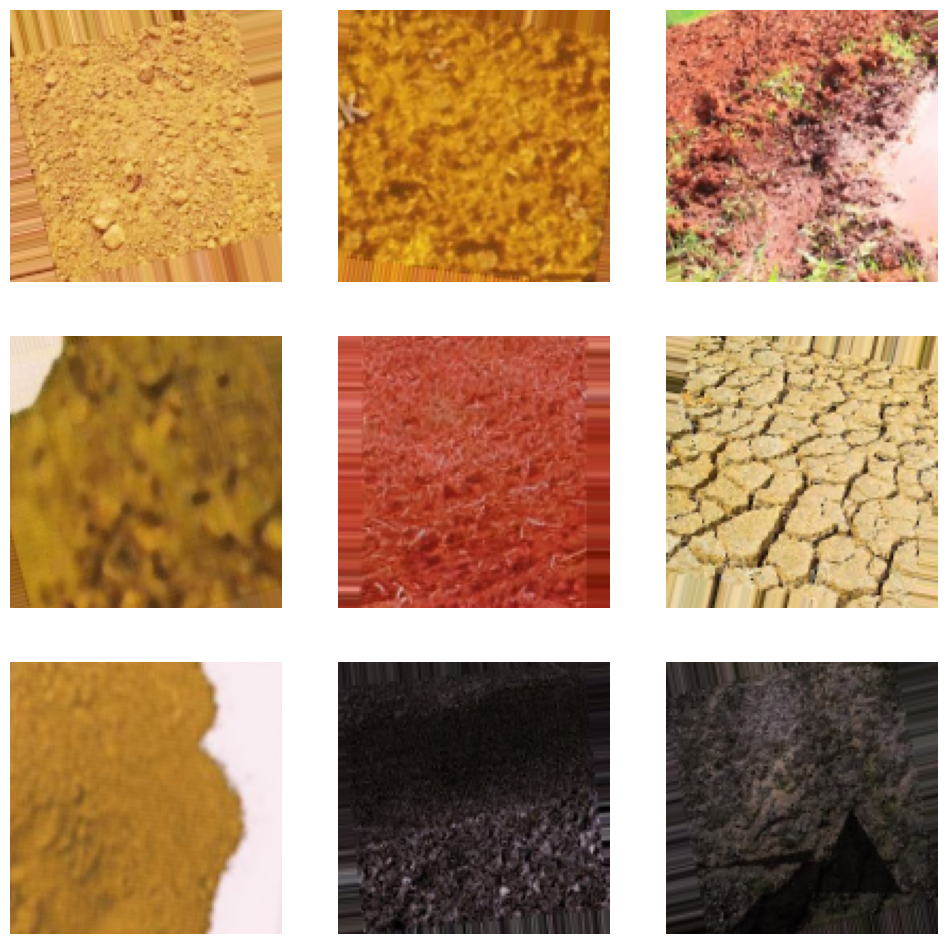

In [12]:
images, labels = next(train_data)

plt.figure(figsize=(12,12))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [13]:
model = Sequential([

    Input(shape=(128,128,3)),

    # CNN BLOCK 1
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # CNN BLOCK 2
    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # CNN BLOCK 3
    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    # CNN BLOCK 4
    Conv2D(256, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    # FLATTEN
    Flatten(),

    # DENSE LAYERS
    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(128, activation='relu'),
    Dropout(0.3),

    # OUTPUT LAYER
    Dense(7, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,359,552 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,782,663 (10.62 MB)

 Trainable params: 2,782,215 (10.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.7934 - loss: 0.6671 - val_accuracy: 0.1368 - val_loss: 2.0523
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 146s 713ms/step - accuracy: 0.8762 - loss: 0.3961 - val_accuracy: 0.1437 - val_loss: 2.8935
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 92s 719ms/step - accuracy: 0.9022 - loss: 0.3102 - val_accuracy: 0.5866 - val_loss: 1.2146
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 93s 726ms/step - accuracy: 0.9108 - loss: 0.2732 - val_accuracy: 0.8533 - val_loss: 0.4084
Epoch 5/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 101s 788ms/step - accuracy: 0.9157 - loss: 0.2672 - val_accuracy: 0.8445 - val_loss: 0.4406
Epoch 6/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 100s 779ms/step - accuracy: 0.9216 - loss: 0.2530 - val_accuracy: 0.8819 - val_loss: 0.3716
Epoch 7/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 128s 998ms/step - accuracy: 0.9297 - loss: 0.2332 - val_accuracy: 0.8720 - val_loss: 0.4309
Epoch 8/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.9331 - loss: 0

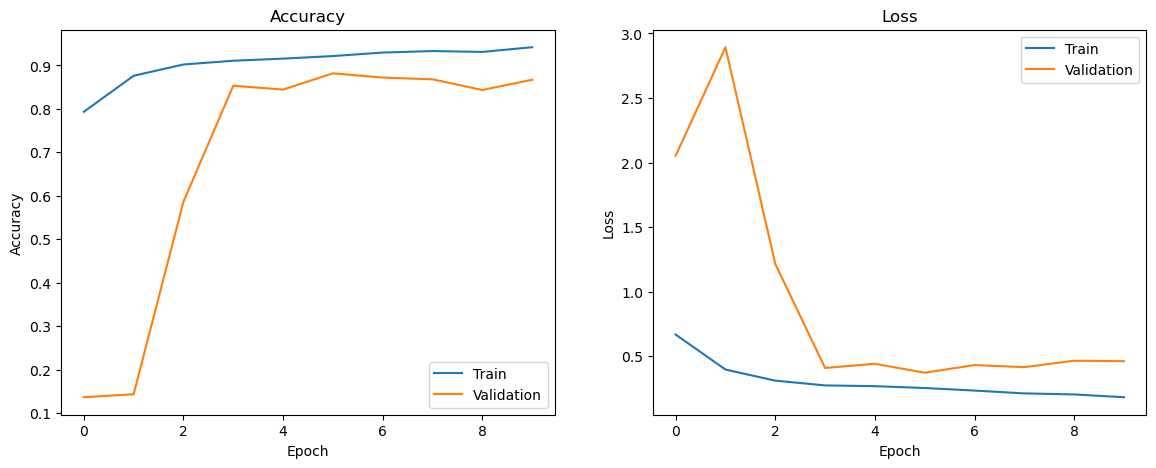

In [17]:
plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

In [18]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)


32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 413ms/step - accuracy: 0.8750 - loss: 0.3735
Validation Accuracy: 0.875
Validation Loss: 0.37352874875068665


In [19]:
model.save(
    r"C:\Users\prince raj\CNN MODEL FOR SOIL QUALITY ANALYSIS\soil_cnn_model.h5"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [23]:
from tensorflow.keras.preprocessing import image

img_path = r"C:\Users\prince raj\CNN MODEL FOR SOIL QUALITY ANALYSIS\test.jpg"

img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

predicted_class = np.argmax(prediction)

class_names = list(train_data.class_indices.keys())

print("Predicted Soil Type:")
print(class_names[predicted_class])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step
Predicted Soil Type:
Black_Soil


In [24]:
# =========================================================
# CELL 21 — CHECK GPU
# =========================================================

print(
    "GPU Available:",
    tf.config.list_physical_devices('GPU')
)

GPU Available: []


In [25]:
confidence = np.max(prediction) * 100

print("Confidence:", confidence, "%")

Confidence: 99.148705 %


In [26]:
# =========================================================
# SOIL INFORMATION DATABASE
# =========================================================

soil_info = {

    "Black_Soil": {
        "crops": ["Cotton", "Soybean", "Wheat", "Sugarcane"],
        "water": "Moderate Water Required",
        "ph": "6.5 - 8.5",
        "nutrients": ["Potassium", "Lime", "Iron"]
    },

    "Red_Soil": {
        "crops": ["Groundnut", "Millets", "Potato", "Rice"],
        "water": "Medium Water Required",
        "ph": "5.5 - 7.0",
        "nutrients": ["Nitrogen", "Phosphorus", "Organic Compost"]
    },

    "Alluvial_Soil": {
        "crops": ["Rice", "Sugarcane", "Wheat", "Maize"],
        "water": "High Water Required",
        "ph": "6.0 - 8.0",
        "nutrients": ["Potash", "Phosphorus", "Humus"]
    },

    "Arid_Soil": {
        "crops": ["Barley", "Millets", "Maize"],
        "water": "Low Water Required",
        "ph": "7.0 - 9.0",
        "nutrients": ["Organic Matter", "Nitrogen"]
    },

    "Laterite_Soil": {
        "crops": ["Tea", "Coffee", "Rubber", "Coconut"],
        "water": "Moderate Water Required",
        "ph": "4.5 - 6.5",
        "nutrients": ["Lime", "Phosphate", "Organic Fertilizer"]
    },

    "Mountain_Soil": {
        "crops": ["Tea", "Coffee", "Spices", "Apple"],
        "water": "Moderate Water Required",
        "ph": "5.0 - 6.5",
        "nutrients": ["Humus", "Nitrogen", "Organic Compost"]
    },

    "Yellow_Soil": {
        "crops": ["Groundnut", "Potato", "Rice"],
        "water": "Moderate Water Required",
        "ph": "5.5 - 7.5",
        "nutrients": ["Nitrogen", "Organic Matter"]
    }
}

In [27]:
# =========================================================
# SOIL PREDICTION + COMPLETE ANALYSIS
# =========================================================

from tensorflow.keras.preprocessing import image
import numpy as np

# IMAGE PATH
img_path = r"C:\Users\prince raj\CNN MODEL FOR SOIL QUALITY ANALYSIS\test.jpg"

# LOAD IMAGE
img = image.load_img(
    img_path,
    target_size=(128,128)
)

# IMAGE TO ARRAY
img_array = image.img_to_array(img)

# NORMALIZATION
img_array = img_array / 255.0

# EXPAND DIMENSIONS
img_array = np.expand_dims(img_array, axis=0)

# PREDICTION
prediction = model.predict(img_array)

# GET CLASS INDEX
predicted_class = np.argmax(prediction)

# CLASS NAMES
class_names = list(train_data.class_indices.keys())

# PREDICTED SOIL
soil_type = class_names[predicted_class]

# CONFIDENCE SCORE
confidence = np.max(prediction) * 100

# GET SOIL INFO
info = soil_info[soil_type]

# =========================================================
# FINAL OUTPUT
# =========================================================

print("\n===================================")
print("      SOIL ANALYSIS REPORT")
print("===================================")

print(f"\nPredicted Soil Type : {soil_type}")

print(f"\nConfidence Score : {confidence:.2f}%")

print("\n===================================")
print("Recommended Crops")
print("===================================")

for crop in info["crops"]:
    print("-", crop)

print("\n===================================")
print("Water Requirement")
print("===================================")

print(info["water"])

print("\n===================================")
print("Recommended Soil pH Range")
print("===================================")

print(info["ph"])

print("\n===================================")
print("Important Nutrients")
print("===================================")

for nutrient in info["nutrients"]:
    print("-", nutrient)

print("\n===================================")
print("   ANALYSIS COMPLETED SUCCESSFULLY")
print("===================================")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step

      SOIL ANALYSIS REPORT

Predicted Soil Type : Black_Soil

Confidence Score : 99.15%

Recommended Crops
- Cotton
- Soybean
- Wheat
- Sugarcane

Water Requirement
Moderate Water Required

Recommended Soil pH Range
6.5 - 8.5

Important Nutrients
- Potassium
- Lime
- Iron

   ANALYSIS COMPLETED SUCCESSFULLY


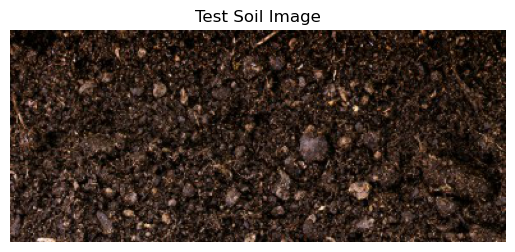

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

      SOIL ANALYSIS REPORT

Predicted Soil Type : Black_Soil

Confidence Score : 99.15%

Recommended Crops
- Cotton
- Soybean
- Wheat
- Sugarcane

Water Requirement
Moderate Water Required

Recommended Soil pH Range
6.5 - 8.5

Important Nutrients
- Potassium
- Lime
- Iron

   ANALYSIS COMPLETED SUCCESSFULLY


In [28]:
# =========================================================
# TEST SAME IMAGE AGAIN
# =========================================================

from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# IMAGE PATH
img_path = r"C:\Users\prince raj\CNN MODEL FOR SOIL QUALITY ANALYSIS\test.jpg"

# DISPLAY IMAGE
img_display = image.load_img(img_path)

plt.imshow(img_display)
plt.title("Test Soil Image")
plt.axis("off")
plt.show()

# LOAD IMAGE FOR MODEL
img = image.load_img(
    img_path,
    target_size=(128,128)
)

# IMAGE TO ARRAY
img_array = image.img_to_array(img)

# NORMALIZE IMAGE
img_array = img_array / 255.0

# EXPAND DIMENSIONS
img_array = np.expand_dims(img_array, axis=0)

# PREDICT
prediction = model.predict(img_array)

# PREDICTED CLASS
predicted_class = np.argmax(prediction)

# CLASS NAMES
class_names = list(train_data.class_indices.keys())

# SOIL TYPE
soil_type = class_names[predicted_class]

# CONFIDENCE
confidence = np.max(prediction) * 100

# SOIL INFO
info = soil_info[soil_type]

# =========================================================
# FINAL REPORT
# =========================================================

print("\n===================================")
print("      SOIL ANALYSIS REPORT")
print("===================================")

print(f"\nPredicted Soil Type : {soil_type}")

print(f"\nConfidence Score : {confidence:.2f}%")

print("\n===================================")
print("Recommended Crops")
print("===================================")

for crop in info["crops"]:
    print("-", crop)

print("\n===================================")
print("Water Requirement")
print("===================================")

print(info["water"])

print("\n===================================")
print("Recommended Soil pH Range")
print("===================================")

print(info["ph"])

print("\n===================================")
print("Important Nutrients")
print("===================================")

for nutrient in info["nutrients"]:
    print("-", nutrient)

print("\n===================================")
print("   ANALYSIS COMPLETED SUCCESSFULLY")
print("===================================")

In [29]:
# =========================================================
# SAVE SOIL INFORMATION
# =========================================================

import json

with open("soil_info.json", "w") as file:
    json.dump(soil_info, file, indent=4)

print("Soil information saved successfully!")

Soil information saved successfully!


In [30]:
# =========================================================
# SAVE CNN MODEL
# =========================================================

model.save("soil_cnn_model.h5")

print("CNN Model Saved Successfully!")

CNN Model Saved Successfully!


In [37]:
import requests
import base64
import time

# API endpoint
API_URL = "https://prince12raj-soil-analysis-api.hf.space/gradio_api/call/predict"

# Your image path
image_path = r"C:\Users\prince raj\CNN MODEL FOR SOIL QUALITY ANALYSIS\test.jpg"

# Convert image to base64
with open(image_path, "rb") as img:
    image_base64 = base64.b64encode(img.read()).decode("utf-8")

# Payload
payload = {
    "data": [
        f"data:image/jpeg;base64,{image_base64}"
    ]
}

# Send prediction request
response = requests.post(API_URL, json=payload)

# Get event ID
event_id = response.json()["event_id"]

print("Event ID:", event_id)

# Result endpoint
result_url = f"{API_URL}/{event_id}"

# Wait for processing
time.sleep(5)

# Fetch final result
result = requests.get(result_url)

print(result.json())

Event ID: 8844dc524f974ba5acdf5c36b2c7303f


JSONDecodeError: Expecting value: line 1 column 1 (char 0)